In [1]:
# import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
from torchvision.models import alexnet
import torchvision.transforms as transforms

import math
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import time

In [2]:
# --- Core Computational Utilities ---

def compute_spectral_norm(matrix):
    """
    Computes the spectral norm of a matrix.
    """
    
    return torch.linalg.matrix_norm(matrix, ord=2)

In [3]:
def compute_l21_norm(matrix):
    """
    Computes the L(2,1) norm of a matrix: L2 norm of columns, then L1 of the result.
    """
    return torch.sum(torch.linalg.norm(matrix, ord=2, dim=0))

In [4]:
# --- Main Calculation Engine ---

def compute_spectral_complexity(model: nn.Module):
    """
    Computes the spectral complexity R_A for a given PyTorch model.
    """
    product_terms = list()
    summation_terms = list()
    
    device = next(model.parameters()).device

    max_layer_time = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            # print(f"Processing layer: {name} of type {type(module).__name__}")

            A_i = module.weight.data
            rho_i = 1.0  # Lipschitz constant for ReLU is 1
            
            start_time = time.perf_counter()

            if A_i.dim() == 4:
                A_i = A_i.view(A_i.size(0), -1)

            print(f"Processing layer: {name} of type {type(module).__name__} and shape {A_i.shape}")
            
            # 1. Compute spectral norm and product term
            s_i = compute_spectral_norm(A_i)
            
            
            
            # 2. Construct the reference matrix M_i
            M_i = torch.zeros_like(A_i)
            
            # 3. Compute the deviation term for the summation
            # Formula requires ||A_i^T - M_i^T||_{2,1}
            deviation_matrix_T = A_i.T - M_i.T
            deviation_norm = compute_l21_norm(deviation_matrix_T)
            

            # Add a small epsilon to avoid division by zero if spectral norm is 0
            # sum_term = (deviation_norm**(2/3)) / ((s_i + 1e-12)**(2/3))
            sum_term = (deviation_norm / s_i)**(2/3)
            end_time = time.perf_counter()

            max_layer_time = max(max_layer_time, end_time - start_time)
            # sum_term = (deviation_norm / s_i)**(2/3)
            summation_terms.append(sum_term)
            product_terms.append(rho_i * s_i)

    # Calculate the final components
    # Product term: prod(rho_i * ||A_i||_sigma)
    total_product = torch.prod(torch.stack(product_terms))
    
    # Summation term: (sum(...))^(3/2)
    total_sum = torch.sum(torch.stack(summation_terms))
    final_sum_term = total_sum**(3/2)
    
    # Final Spectral Complexity R_A
    R_A = total_product * final_sum_term

    print(f"Maximum Computation Time for Layer: {max_layer_time:.4f}s")
    
    return R_A, total_product, final_sum_term

In [5]:
def compute_gamma_distribution(model_path, train = False, subset_size = None):
    print("Loading pretrained AlexNet model...")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Cifar10AlexNet().to(device)
    
    model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))
        
    # Set the model to evaluation mode
    model.eval()
        
    # Compute the spectral complexity
    print("\nComputing spectral complexity...")
    start_time = time.perf_counter()
    spectral_complexity, product_component, sum_component = compute_spectral_complexity(model)
    end_time = time.perf_counter()
    print(f"Total Computation Time: {end_time - start_time:.4f}s")
        
    print("\n--- Results ---")
    print(f"Product Component (Lipschitz-like term): {product_component.item():.4e}")
    print(f"Summation Component (Structural Deviation term): {sum_component.item():.4e}")
    print(f"Total Spectral Complexity (R_A): {spectral_complexity.item():.4e}")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
    ])
    testset = torchvision.datasets.CIFAR10(root='./data', train=train, download=True, transform=transform)

    if subset_size is not None:
        total_size = len(testset)
        print(f"Testset size is: {total_size}")
        if subset_size < 1 and subset_size > 0:
            subset_size = int(subset_size * total_size)
        elif subset_size <= 0:
            raise ValueError("Sorry, negative numbers as subset_size are not allowed")
        else:
            subset_size = int(subset_size)
        remainder_size = total_size - subset_size
        
        # Randomly split the dataset
        generator = torch.Generator().manual_seed(42)
        testset, _ = torch.utils.data.random_split(testset, [subset_size, remainder_size], generator=generator)
    
    testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    num_samples = len(testset)
    data_l2_norm = 0
    
    diffs = []
    
    with torch.no_grad():
        pbar = tqdm(testloader, desc=f"Eval: ")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            # 1. Get the score corresponding to the target class
            # We use torch.arange to index the rows, and targets to index the columns
            batch_indices = torch.arange(inputs.size(0)).to(device)
            target_scores = outputs[batch_indices, targets]
            
            # 2. Find the max of non-target classes
            # Create a clone so we don't modify the original outputs
            outputs_without_target = outputs.clone()
            
            # Set the target indices to -infinity so they are never selected as max
            outputs_without_target[batch_indices, targets] = -float('inf')
            
            # Now taking the max gives us the highest score among the "wrong" classes
            max_others = torch.max(outputs_without_target, dim=1).values
            
            # 3. Calculate difference (Target - Max(Others))
            diffs.extend((target_scores - max_others).cpu().numpy())
            data_l2_norm += torch.sum(inputs**2)

    normal_diffs = np.array(diffs)/(spectral_complexity.item() * (torch.sqrt(data_l2_norm) / num_samples))

    return normal_diffs

    # return np.array(diffs)

In [7]:
overfit_test = compute_gamma_distribution("ckpt_alexnet_cifar10_overfit/epoch_500.pth", False)
correct_test = compute_gamma_distribution("ckpt_alexnet_cifar10/epoch_1000.pth", False)

Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0469s
Total Computation Time: 0.1661s

--- Results ---
Product Component (Lipschitz-like term): 5.4933e+02
Summation Component (Structural Deviation term): 1.1069e+03
Total Spectral Complexity (R_A): 6.0807e+05


Eval: 100%|██████████| 79/79 [00:01<00:00, 46.39it/s]


Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0292s
Total Computation Time: 0.1143s

--- Results ---
Product Component (Lipschitz-like term): 1.1502e+02
Summation Component (Structural Deviation term): 1.0755e+03
Total Spectral Complexity (R_A): 1.2370e+05


Eval: 100%|██████████| 79/79 [00:01<00:00, 67.96it/s]


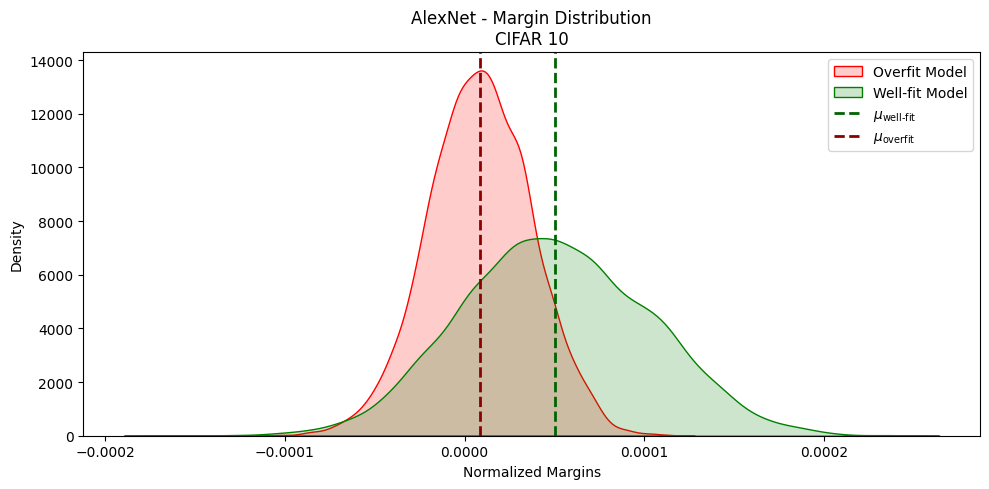

In [8]:
ote = overfit_test.mean()
cte = correct_test.mean()


plt.figure(figsize=(10, 5))
sns.kdeplot(overfit_test, fill=True, color="red", label="Overfit Model", alpha=0.2)
sns.kdeplot(correct_test, fill=True, color="green", label="Well-fit Model", alpha=0.2)

plt.axvline(cte, color='darkgreen', linestyle='dashed', linewidth=2, label = r"$\mu_{\text{well-fit}}$")
plt.axvline(ote, color='darkred', linestyle='dashed', linewidth=2, label = r"$\mu_{\text{overfit}}$")

plt.xlabel("Normalized Margins")
plt.ylabel("Density")
plt.title(f"AlexNet - Margin Distribution\nCIFAR 10")
plt.legend()
plt.tight_layout()
plt.savefig("margin_kde_alexnet_cifar10_re_vs_overfit.png")
plt.show()

In [9]:
subset_size = 56
overfit_test = compute_gamma_distribution("ckpt_alexnet_cifar10_overfit/epoch_500.pth", False, subset_size)
correct_test = compute_gamma_distribution("ckpt_alexnet_cifar10/epoch_1000.pth", False)

Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0119s
Total Computation Time: 0.0582s

--- Results ---
Product Component (Lipschitz-like term): 5.4933e+02
Summation Component (Structural Deviation term): 1.1069e+03
Total Spectral Complexity (R_A): 6.0807e+05
Testset size is: 10000


Eval: 100%|██████████| 1/1 [00:00<00:00,  8.70it/s]

Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])


Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0158s
Total Computation Time: 0.0818s

--- Results ---
Product Component (Lipschitz-like term): 1.1502e+02
Summation Component (Structural Deviation term): 1.0755e+03
Total Spectral Complexity (R_A): 1.2370e+05


Eval: 100%|██████████| 79/79 [00:01<00:00, 39.51it/s]


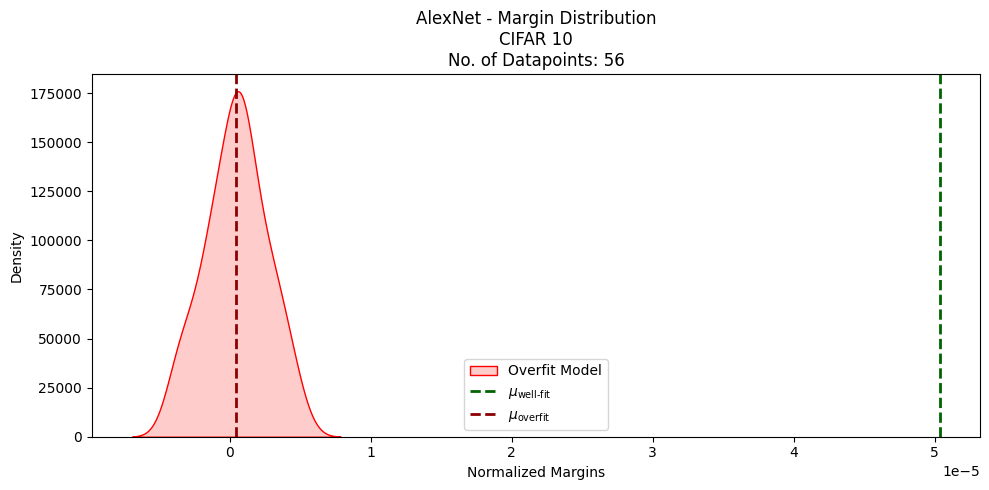

In [10]:
ote = overfit_test.mean()
cte = correct_test.mean()


plt.figure(figsize=(10, 5))
sns.kdeplot(overfit_test, fill=True, color="red", label="Overfit Model", alpha=0.2)
# sns.kdeplot(correct_test, fill=True, color="green", label="Well-fit Model", alpha=0.2)

plt.axvline(cte, color='darkgreen', linestyle='dashed', linewidth=2,  label = r"$\mu_{\text{well-fit}}$")
plt.axvline(ote, color='darkred', linestyle='dashed', linewidth=2,  label = r"$\mu_{\text{overfit}}$")

plt.xlabel("Normalized Margins")
plt.ylabel("Density")
plt.title(f"AlexNet - Margin Distribution\nCIFAR 10\nNo. of Datapoints: {subset_size}")
plt.legend()
plt.tight_layout()
plt.savefig(f"margin_kde_alexnet_cifar10_re_vs_overfit_{subset_size}.png")
plt.show()

In [11]:
overfit_test = compute_gamma_distribution("ckpt_alexnet_cifar10_overfit/epoch_500.pth", False)
slight_overfit_test = compute_gamma_distribution("ckpt_alexnet_cifar10_overfit/epoch_40.pth", False)

Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0084s
Total Computation Time: 0.0404s

--- Results ---
Product Component (Lipschitz-like term): 5.4933e+02
Summation Component (Structural Deviation term): 1.1069e+03
Total Spectral Complexity (R_A): 6.0807e+05


Eval: 100%|██████████| 79/79 [00:02<00:00, 35.50it/s]


Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0072s
Total Computation Time: 0.0314s

--- Results ---
Product Component (Lipschitz-like term): 3.3476e+02
Summation Component (Structural Deviation term): 1.1336e+03
Total Spectral Complexity (R_A): 3.7947e+05


Eval: 100%|██████████| 79/79 [00:02<00:00, 35.94it/s]


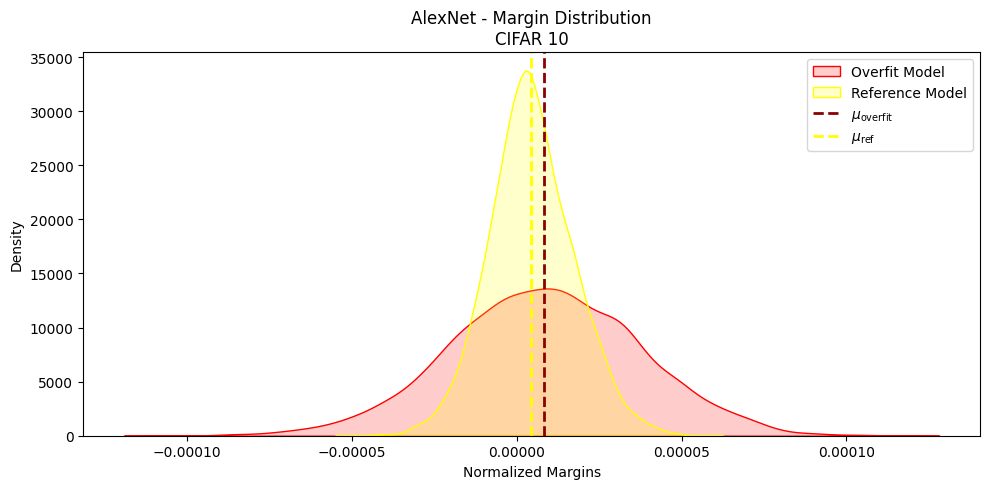

In [12]:
ote = overfit_test.mean()
ste = slight_overfit_test.mean()
# cte = np.mean(correct_test)


plt.figure(figsize=(10, 5))
sns.kdeplot(overfit_test, fill=True, color="red", label="Overfit Model", alpha=0.2)
# sns.kdeplot(correct_test, fill=True, color="green", label="Reference Model", alpha=0.2)
sns.kdeplot(slight_overfit_test, fill=True, color="yellow", label="Reference Model", alpha=0.2)

# plt.axvline(cte, color='darkgreen', linestyle='dashed', linewidth=2,  label = "Mean Reference Model")
plt.axvline(ote, color='darkred', linestyle='dashed', linewidth=2,  label = r"$\mu_{\text{overfit}}$")
plt.axvline(ste, color='yellow', linestyle='dashed', linewidth=2,  label = r"$\mu_{\text{ref}}$")
# plt.xlim(-1e-9,1e-9)
plt.xlabel("Normalized Margins")
plt.ylabel("Density")
plt.title(f"AlexNet - Margin Distribution\nCIFAR 10")
plt.legend()
plt.tight_layout()
plt.savefig(f"margin_kde_alexnet_cifar10_full_vs_slight.png")
plt.show()

In [13]:
overfit_test = compute_gamma_distribution("ckpt_alexnet_cifar10_overfit/epoch_500.pth", False)
slight_overfit_test = compute_gamma_distribution("ckpt_alexnet_cifar10_overfit/epoch_40.pth", False)
correct_test = compute_gamma_distribution("ckpt_alexnet_cifar10/epoch_1000.pth", False)

Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0105s
Total Computation Time: 0.0407s

--- Results ---
Product Component (Lipschitz-like term): 5.4933e+02
Summation Component (Structural Deviation term): 1.1069e+03
Total Spectral Complexity (R_A): 6.0807e+05


Eval: 100%|██████████| 79/79 [00:02<00:00, 37.72it/s]


Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0084s
Total Computation Time: 0.0440s

--- Results ---
Product Component (Lipschitz-like term): 3.3476e+02
Summation Component (Structural Deviation term): 1.1336e+03
Total Spectral Complexity (R_A): 3.7947e+05


Eval: 100%|██████████| 79/79 [00:02<00:00, 37.38it/s]


Loading pretrained AlexNet model...

Computing spectral complexity...
Processing layer: features.0 of type Conv2d and shape torch.Size([32, 75])
Processing layer: features.4 of type Conv2d and shape torch.Size([64, 800])
Processing layer: features.8 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.12 of type Conv2d and shape torch.Size([64, 576])
Processing layer: features.15 of type Conv2d and shape torch.Size([64, 576])
Processing layer: classifier.2 of type Linear and shape torch.Size([256, 256])
Processing layer: classifier.5 of type Linear and shape torch.Size([128, 256])
Processing layer: classifier.7 of type Linear and shape torch.Size([10, 128])
Maximum Computation Time for Layer: 0.0072s
Total Computation Time: 0.0320s

--- Results ---
Product Component (Lipschitz-like term): 1.1502e+02
Summation Component (Structural Deviation term): 1.0755e+03
Total Spectral Complexity (R_A): 1.2370e+05


Eval: 100%|██████████| 79/79 [00:01<00:00, 45.05it/s]


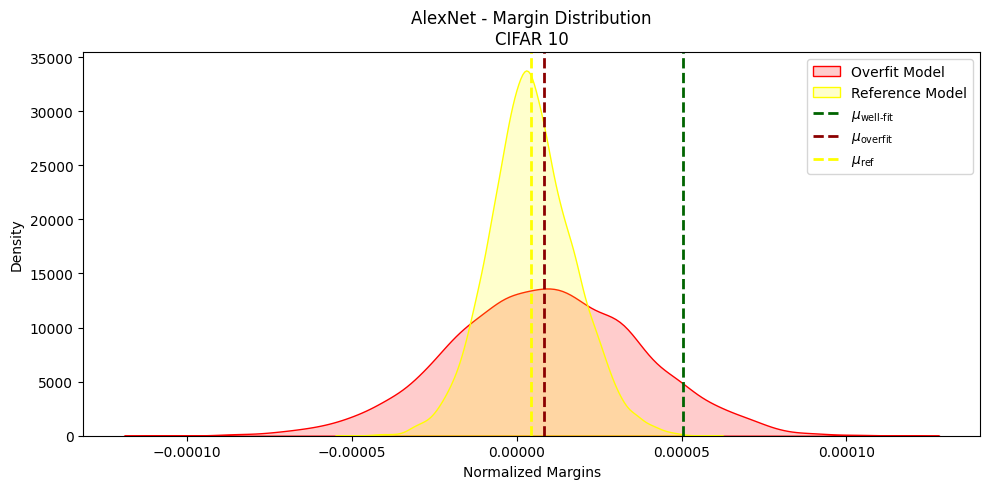

In [14]:
ote = overfit_test.mean()
ste = slight_overfit_test.mean()
# cte = np.mean(correct_test)


plt.figure(figsize=(10, 5))
sns.kdeplot(overfit_test, fill=True, color="red", label="Overfit Model", alpha=0.2)
# sns.kdeplot(correct_test, fill=True, color="green", label="Reference Model", alpha=0.2)
sns.kdeplot(slight_overfit_test, fill=True, color="yellow", label="Reference Model", alpha=0.2)

plt.axvline(cte, color='darkgreen', linestyle='dashed', linewidth=2,  label = r"$\mu_{\text{well-fit}}$")
plt.axvline(ote, color='darkred', linestyle='dashed', linewidth=2,  label = r"$\mu_{\text{overfit}}$")
plt.axvline(ste, color='yellow', linestyle='dashed', linewidth=2,  label = r"$\mu_{\text{ref}}$")
# plt.xlim(-1e-9,1e-9)
plt.xlabel("Normalized Margins")
plt.ylabel("Density")
plt.title(f"AlexNet - Margin Distribution\nCIFAR 10")
plt.legend()
plt.tight_layout()
plt.savefig(f"margin_kde_alexnet_cifar10_all3.png")
plt.show()

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

In [6]:
class Cifar10AlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        """
        A Narrow AlexNet adapted for CIFAR-10 (32x32 inputs).
        
        Args:
            num_classes (int): Number of output classes (10 for CIFAR-10).
            dropout (float): Dropout probability. Set to 0.0 to disable for overfitting.
        """
        super(Cifar10AlexNet, self).__init__()
        
        # Feature Extractor
        # Input: 32x32x3
        self.features = nn.Sequential(
            # Conv 1
            # Standard AlexNet uses 11x11 stride 4. We use 5x5 stride 1 for 32x32 img.
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 16x16
            
            # Conv 2
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 8x8
            
            # Conv 3
            # Limited to 64 channels
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 4x4
            
            # Conv 4
            # Limited to 64 channels
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            # Conv 5
            # Limited to 64 channels
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: 2x2
        )
        
        # Classifier
        # Input size is 64 channels * 4 * 4 spatial dimension = 1024
        self.classifier = nn.Sequential(
            nn.Flatten(),
            
            # FC 1
            nn.Dropout(p=dropout),
            nn.Linear(64 * 2 * 2, 256, bias=True),
            nn.ReLU(inplace=True),
            
            # FC 2
            nn.Dropout(p=dropout),
            nn.Linear(256, 128, bias=True),
            nn.ReLU(inplace=True),
            
            # Output Layer
            nn.Linear(128, num_classes, bias=True)
        )

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Cifar10AlexNet().to(device)

In [8]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200) # Optional: Learning rate scheduler

epochs = 500 # Adjust as needed

train_acc = list()
test_acc = list()
train_loss = list()
test_loss = list()

for epoch in range(epochs):
    model.train()
    train_running_loss = 0.0
    test_running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}, Train: ")
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    train_acc_ = 100 * correct / total
    scheduler.step() # If using a scheduler

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(testloader, desc=f"Eval: ")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    test_acc_ = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {train_running_loss/len(trainloader):.4f}, train acc: {train_acc_:.2f}%, test acc: {test_acc_:.2f}%")
    train_acc.append(train_acc_)
    test_acc.append(test_acc_)
    train_loss.append(train_running_loss/len(trainloader))
    test_loss.append(test_running_loss/len(testloader))
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"ckpt_alexnet_cifar10_overfit/epoch_{epoch+1}.pth")

Eval: 100%|██████████| 79/79 [00:02<00:00, 35.08it/s]


Epoch 1, Loss: 2.0515, train acc: 27.78%, test acc: 36.70%


Eval: 100%|██████████| 79/79 [00:02<00:00, 36.74it/s]


Epoch 2, Loss: 1.6469, train acc: 39.87%, test acc: 42.26%


Eval: 100%|██████████| 79/79 [00:02<00:00, 36.64it/s]


...

Eval: 100%|██████████| 79/79 [00:02<00:00, 32.43it/s]


Epoch 297, Loss: 0.0098, train acc: 100.00%, test acc: 61.35%


Eval: 100%|██████████| 79/79 [00:02<00:00, 33.71it/s]


Epoch 298, Loss: 0.0094, train acc: 100.00%, test acc: 61.42%


Epoch 299/500, Train:  89%|████████▉ | 87/98 [00:21<00:02,  5.39it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



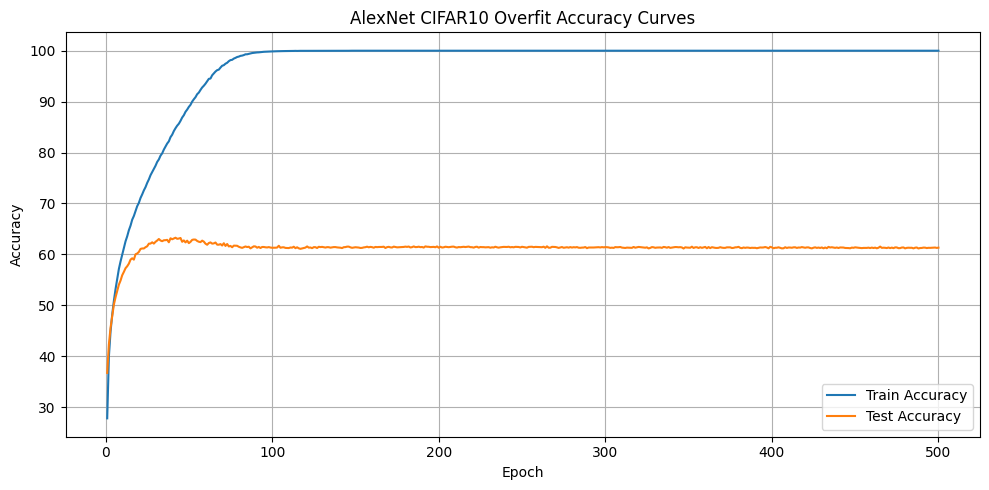

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_acc, label="Train Accuracy")
plt.plot(range(1, epochs + 1), test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"AlexNet CIFAR10 Overfit Accuracy Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"alexnet_cifar10_overfit_accuracy_curve.png")
plt.show()

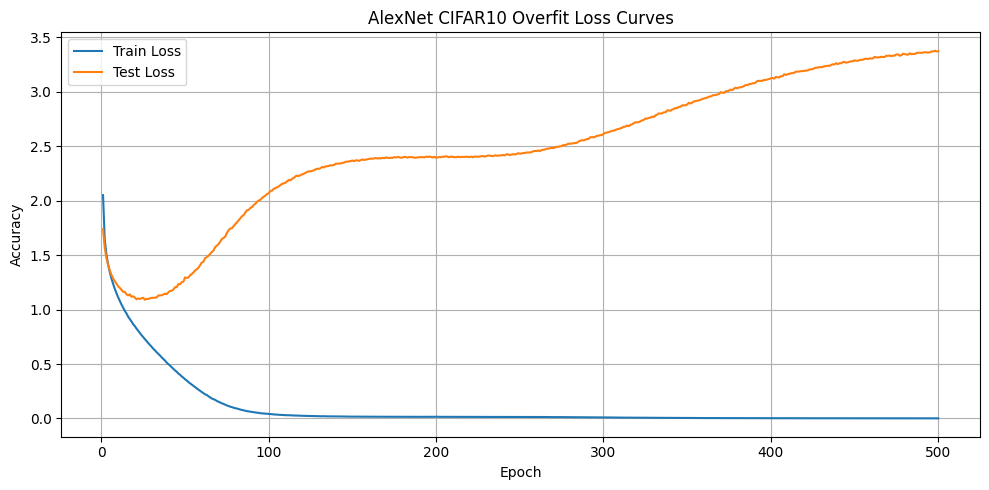

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss, label="Train Loss")
plt.plot(range(1, epochs + 1), test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"AlexNet CIFAR10 Overfit Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"alexnet_cifar10_overfit_loss_curve.png")
plt.show()

In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10 mean/std
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=512, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Cifar10AlexNet().to(device)

In [5]:
criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200) # Optional: Learning rate scheduler

epochs = 1000 # Adjust as needed

train_acc = list()
test_acc = list()
train_loss = list()
test_loss = list()

for epoch in range(epochs):
    model.train()
    train_running_loss = 0.0
    test_running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}, Train: ")
    for batch_idx, (inputs, targets) in enumerate(pbar):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    train_acc_ = 100 * correct / total
    scheduler.step() # If using a scheduler

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(testloader, desc=f"Eval: ")
        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    test_acc_ = 100 * correct / total
    print(f"Epoch {epoch+1}, Loss: {train_running_loss/len(trainloader):.4f}, train acc: {train_acc_:.2f}%, test acc: {test_acc_:.2f}%")
    train_acc.append(train_acc_)
    test_acc.append(test_acc_)
    train_loss.append(train_running_loss/len(trainloader))
    test_loss.append(test_running_loss/len(testloader))
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"ckpt_alexnet_cifar10/epoch_{epoch+1}.pth")

Eval: 100%|██████████| 79/79 [00:01<00:00, 60.56it/s]


Epoch 1, Loss: 2.0774, train acc: 24.55%, test acc: 33.10%


Eval: 100%|██████████| 79/79 [00:01<00:00, 65.17it/s]


Epoch 2, Loss: 1.7751, train acc: 34.59%, test acc: 38.49%


Eval: 100%|██████████| 79/79 [00:01<00:00, 65.21it/s]


...

Epoch 998, Loss: 0.3004, train acc: 89.35%, test acc: 82.98%


Eval: 100%|██████████| 79/79 [00:01<00:00, 62.62it/s]


Epoch 999, Loss: 0.3020, train acc: 89.47%, test acc: 82.99%


Eval: 100%|██████████| 79/79 [00:01<00:00, 63.94it/s]

Epoch 1000, Loss: 0.3000, train acc: 89.45%, test acc: 82.97%


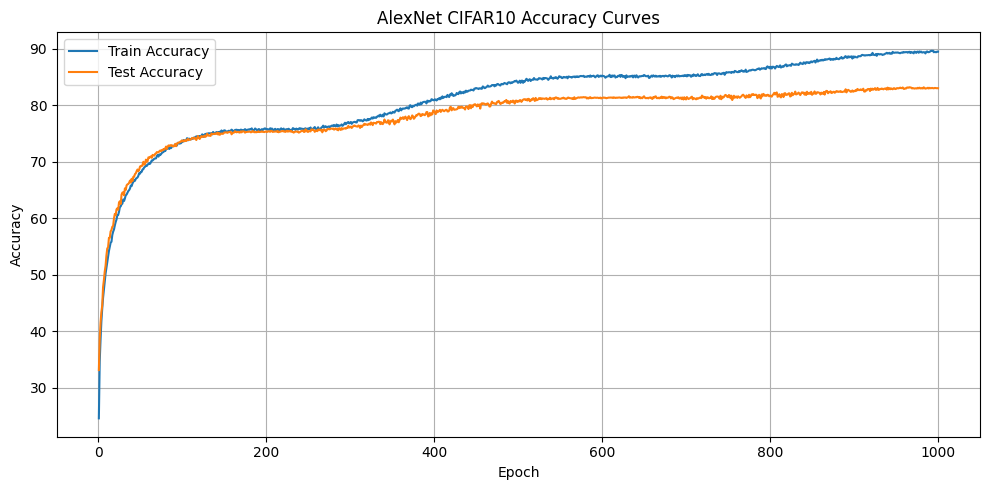

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_acc, label="Train Accuracy")
plt.plot(range(1, epochs + 1), test_acc, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"AlexNet CIFAR10 Accuracy Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"alexnet_cifar10_normal_accuracy_curve.png")
plt.show()

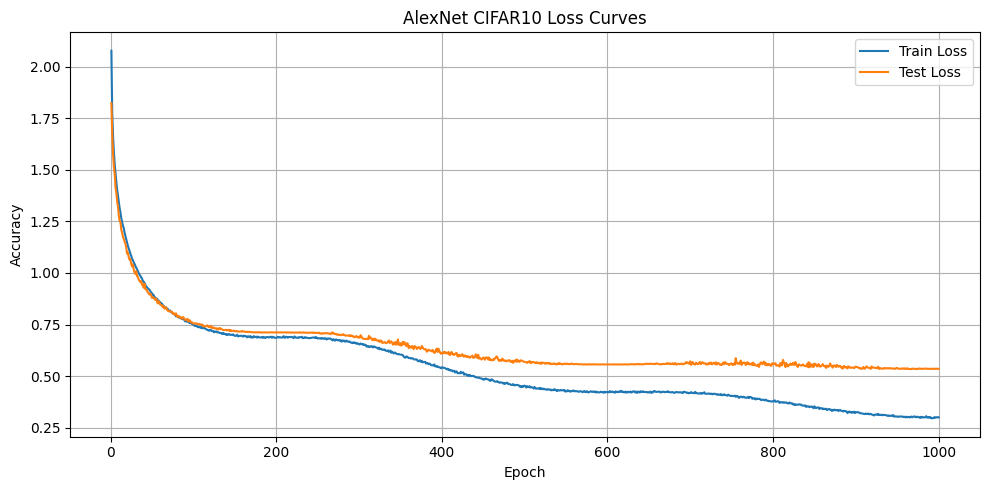

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss, label="Train Loss")
plt.plot(range(1, epochs + 1), test_loss, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"AlexNet CIFAR10 Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"alexnet_cifar10_normal_loss_curve.png")
plt.show()